# NYC Airbnb Pricing Analysis

Exploratory analysis of NYC Airbnb listings, focused on what drives price differences
across boroughs, room types, and hosts.

Data source: Inside Airbnb (NYC listings scrape). Listings missing a price were dropped,
and the top 1% by price is flagged separately as a `luxury` segment.

## Average Price by Borough

In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/processed/airbnb.db")
df = pd.read_sql("SELECT * FROM listings", conn)

df.shape

(20331, 20)

In [8]:
query = """
SELECT neighbourhood_group, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price
FROM listings
WHERE segment = 'mainstream'
GROUP BY neighbourhood_group
ORDER BY avg_price DESC
"""
borough_prices = pd.read_sql(query, conn)
borough_prices

,neighbourhood_group,num_listings,avg_price
0,Manhattan,9087,298.53
1,Brooklyn,6670,195.22
2,Queens,3303,158.22
3,Staten Island,281,139.56
4,Bronx,786,129.45


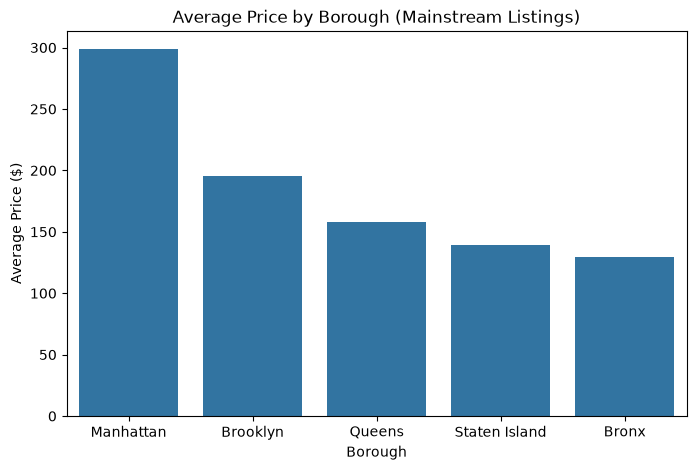

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=borough_prices, x="neighbourhood_group", y="avg_price", order=borough_prices["neighbourhood_group"])
plt.title("Average Price by Borough (Mainstream Listings)")
plt.xlabel("Borough")
plt.ylabel("Average Price ($)")
plt.savefig("../outputs/figures/avg_price_by_borough.png", dpi=150, bbox_inches="tight")
plt.show()

## Average Price by Room Type

In [10]:
query = """
SELECT room_type, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price
FROM listings
WHERE segment = 'mainstream'
GROUP BY room_type
ORDER BY avg_price DESC
"""
room_type_prices = pd.read_sql(query, conn)
room_type_prices

,room_type,num_listings,avg_price
0,Hotel room,420,471.84
1,Entire home/apt,10685,276.22
2,Private room,8871,169.82
3,Shared room,151,147.77


## Average Price by Borough and Room Type

In [11]:
query = """
SELECT neighbourhood_group, room_type, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price
FROM listings
WHERE segment = 'mainstream'
GROUP BY neighbourhood_group, room_type
ORDER BY neighbourhood_group, avg_price DESC
"""
borough_room_prices = pd.read_sql(query, conn)
borough_room_prices

,neighbourhood_group,room_type,num_listings,avg_price
0,Bronx,Entire home/apt,296,169.93
1,Bronx,Hotel room,4,139.00
2,Bronx,Private room,486,104.72
3,Brooklyn,Hotel room,40,281.25
4,Brooklyn,Entire home/apt,3242,248.18
5,Brooklyn,Shared room,70,161.10
6,Brooklyn,Private room,3318,143.15
7,Manhattan,Hotel room,301,532.40
8,Manhattan,Entire home/apt,5772,316.26
9,Manhattan,Private room,2971,242.97


## Luxury Segment

So far the borough and room type breakdowns only used mainstream listings.
Here we look specifically at the top 1% of listings by price (the luxury segment)
to see where they're concentrated.

In [12]:
query = """
SELECT segment, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price,
       ROUND(MIN(price), 2) AS min_price, ROUND(MAX(price), 2) AS max_price
FROM listings
GROUP BY segment
"""
segment_overview = pd.read_sql(query, conn)
segment_overview

,segment,num_listings,avg_price,min_price,max_price
0,luxury,204,3713.27,1678.0,31211.0
1,mainstream,20127,232.44,5.0,1672.0


In [13]:
query = """
SELECT neighbourhood_group, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price
FROM listings
WHERE segment = 'luxury'
GROUP BY neighbourhood_group
ORDER BY num_listings DESC
"""
luxury_by_borough = pd.read_sql(query, conn)
luxury_by_borough

,neighbourhood_group,num_listings,avg_price
0,Manhattan,169,3619.49
1,Brooklyn,21,3599.52
2,Queens,9,5468.78
3,Bronx,4,4652.75
4,Staten Island,1,2394.00


In [14]:
query = """
SELECT room_type, COUNT(*) AS num_listings, ROUND(AVG(price), 2) AS avg_price
FROM listings
WHERE segment = 'luxury'
GROUP BY room_type
ORDER BY num_listings DESC
"""
luxury_by_room_type = pd.read_sql(query, conn)
luxury_by_room_type

,room_type,num_listings,avg_price
0,Entire home/apt,122,3390.84
1,Private room,58,4247.71
2,Hotel room,22,4228.59
3,Shared room,2,2214.00
